In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("C:\\Users\\LENOVO\\OneDrive\\Desktop\\Machine learning project\\gurgaon_properties_cleaned_v2.xls")

In [7]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,mapsko mount ville,sector 79,1.30,8024.0,1620.0,Super Built up area 1620(150.5 sq.m.)Carpet ar...,3,3,2,...,1620.0,NaN,867.24,1,0,0,1,0,0,151
1,flat,experion windchants,sector 112,5.20,10726.0,4848.0,Super Built up area 4848(450.39 sq.m.)Built Up...,4,6,3+,...,4848.0,3655.350000,3500.00,0,1,0,1,0,1,174
2,flat,signature global park,sohna road,0.95,7846.0,1211.0,Built Up area: 1210.73 (112.48 sq.m.)Carpet ar...,3,2,3+,...,NaN,1210.723472,756.60,0,0,0,0,0,0,46
3,house,nirvana cedar crest,sector 50,3.99,8866.0,4500.0,Plot area 4500(418.06 sq.m.),4,5,3+,...,NaN,4500.000000,NaN,0,1,0,0,0,1,112
4,flat,tulip violet,sector 69,1.40,8861.0,1580.0,Super Built up area 1578(146.6 sq.m.),3,3,2,...,1578.0,NaN,NaN,0,0,0,1,0,0,102


In [9]:
df.shape

(3803, 23)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3803 entries, 0 to 3802
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3803 non-null   object 
 1   society              3802 non-null   object 
 2   sector               3803 non-null   object 
 3   price                3785 non-null   float64
 4   price_per_sqft       3785 non-null   float64
 5   area                 3785 non-null   float64
 6   areaWithType         3803 non-null   object 
 7   bedRoom              3803 non-null   int64  
 8   bathroom             3803 non-null   int64  
 9   balcony              3803 non-null   object 
 10  floorNum             3784 non-null   float64
 11  facing               2698 non-null   object 
 12  agePossession        3803 non-null   object 
 13  super_built_up_area  1915 non-null   float64
 14  built_up_area        1733 non-null   float64
 15  carpet_area          1944 non-null   f

In [13]:
df.duplicated().sum()

124

In [15]:
df.drop_duplicates(inplace=True)

In [17]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,mapsko mount ville,sector 79,1.30,8024.0,1620.0,Super Built up area 1620(150.5 sq.m.)Carpet ar...,3,3,2,...,1620.0,NaN,867.24,1,0,0,1,0,0,151
1,flat,experion windchants,sector 112,5.20,10726.0,4848.0,Super Built up area 4848(450.39 sq.m.)Built Up...,4,6,3+,...,4848.0,3655.350000,3500.00,0,1,0,1,0,1,174
2,flat,signature global park,sohna road,0.95,7846.0,1211.0,Built Up area: 1210.73 (112.48 sq.m.)Carpet ar...,3,2,3+,...,NaN,1210.723472,756.60,0,0,0,0,0,0,46
3,house,nirvana cedar crest,sector 50,3.99,8866.0,4500.0,Plot area 4500(418.06 sq.m.),4,5,3+,...,NaN,4500.000000,NaN,0,1,0,0,0,1,112
4,flat,tulip violet,sector 69,1.40,8861.0,1580.0,Super Built up area 1578(146.6 sq.m.),3,3,2,...,1578.0,NaN,NaN,0,0,0,1,0,0,102


<Axes: xlabel='property_type'>

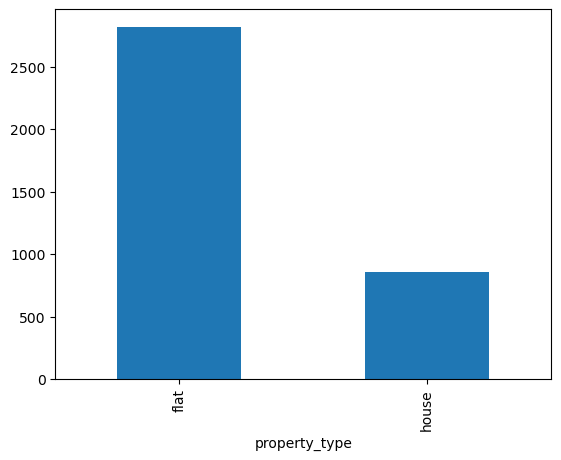

In [20]:
df['property_type'].value_counts().plot(kind='bar',)

In [22]:
#society
df['society'].value_counts().shape

(676,)

In [24]:
df['society'].value_counts()

society
independent                             486
tulip violet                             75
ss the leaf                              73
dlf new town heights                     42
shapoorji pallonji joyville gurugram     42
                                       ... 
bestech park view aindependentda          1
grover homes sec 4                        1
sbr minda sec 1 imt manesar               1
kibithu villas                            1
vatika iris floors                        1
Name: count, Length: 676, dtype: int64

In [26]:
df[df['society'] != 'independent']['society'].value_counts(normalize=True).cumsum().head(75)

society
tulip violet                            0.023496
ss the leaf                             0.046366
dlf new town heights                    0.059524
shapoorji pallonji joyville gurugram    0.072682
signature global park                   0.083647
                                          ...   
ansal heights 86                        0.489975
unitech uniworld resorts                0.494048
puri emerald bay                        0.498120
ramsons kshitij                         0.502193
ireo the corridors                      0.505952
Name: proportion, Length: 75, dtype: float64

In [28]:
society_counts = df['society'].value_counts()

# Frequency distribution for societies
frequency_bins = {
    "Very High (>100)": (society_counts > 100).sum(),
    "High (50-100)": ((society_counts >= 50) & (society_counts <= 100)).sum(),
    "Average (10-49)": ((society_counts >= 10) & (society_counts < 50)).sum(),
    "Low (2-9)": ((society_counts > 1) & (society_counts < 10)).sum(),
    "Very Low (1)": (society_counts == 1).sum()
}
frequency_bins

{'Very High (>100)': 1,
 'High (50-100)': 2,
 'Average (10-49)': 92,
 'Low (2-9)': 274,
 'Very Low (1)': 307}

<Axes: xlabel='society'>

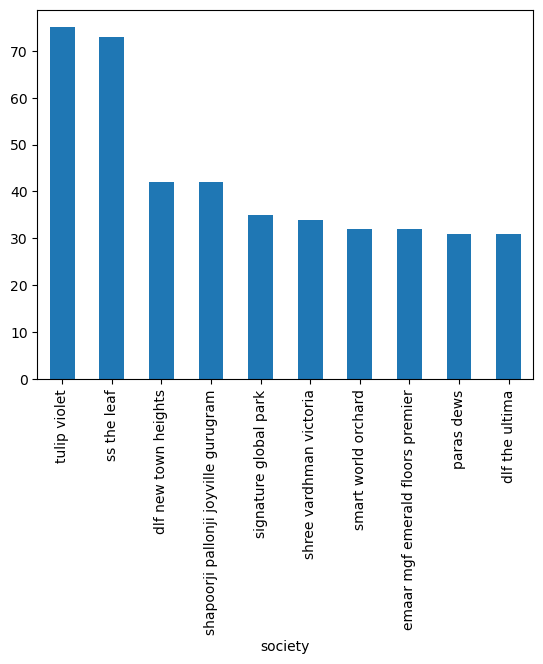

In [30]:
# top 10 socities
df[df['society'] != 'independent']['society'].value_counts().head(10).plot(kind='bar')

In [32]:
df['society'].isnull().sum()

1

In [34]:
df[df['society'].isnull()]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2271,flat,NaN,sector 78,0.6,3692.0,1625.0,Built Up area: 1625 (150.97 sq.m.),2,2,0,...,NaN,1625.0,NaN,0,0,0,0,0,0,0


In [36]:
#sector

In [38]:
# unique sectors
df['sector'].value_counts().shape

(115,)

<Axes: xlabel='sector'>

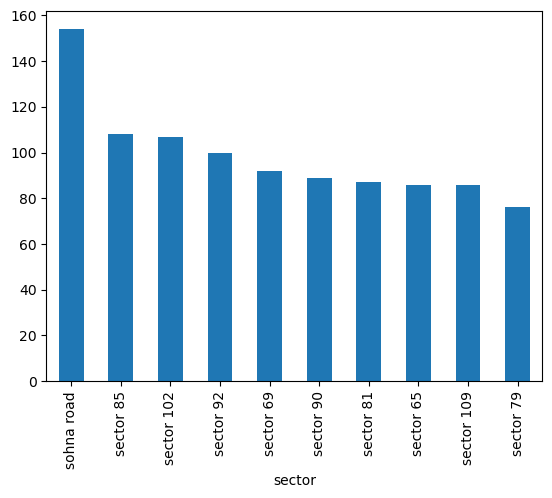

In [40]:
# top 10 sectors
df['sector'].value_counts().head(10).plot(kind='bar')

In [42]:
# Frequency distribution for sectors
sector_counts = df['sector'].value_counts()

sector_frequency_bins = {
    "Very High (>100)": (sector_counts > 100).sum(),
    "High (50-100)": ((sector_counts >= 50) & (sector_counts <= 100)).sum(),
    "Average (10-49)": ((sector_counts >= 10) & (sector_counts < 50)).sum(),
    "Low (2-9)": ((sector_counts > 1) & (sector_counts < 10)).sum(),
    "Very Low (1)": (sector_counts == 1).sum()
}

sector_frequency_bins

{'Very High (>100)': 3,
 'High (50-100)': 25,
 'Average (10-49)': 63,
 'Low (2-9)': 23,
 'Very Low (1)': 1}

In [45]:
df['price'].isnull().sum()

18

In [47]:
df['price'].describe()

count    3661.000000
mean        2.534119
std         2.980344
min         0.070000
25%         0.950000
50%         1.520000
75%         2.750000
max        31.500000
Name: price, dtype: float64

<Axes: xlabel='price', ylabel='Count'>

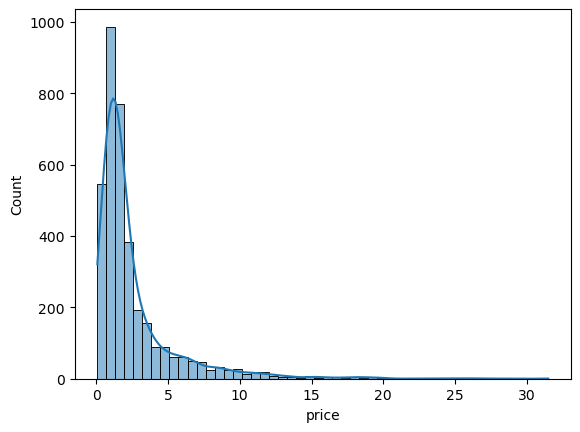

In [49]:
sns.histplot(df['price'], kde=True, bins=50)

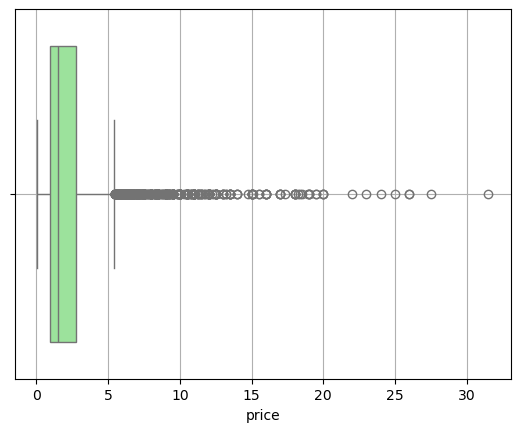

In [51]:
sns.boxplot(x=df['price'], color='lightgreen')
plt.grid()

In [53]:
# Skewness and Kurtosis
skewness = df['price'].skew()
kurtosis = df['price'].kurt()

print(skewness,kurtosis)

3.2787873710645883 14.933224882482042


In [55]:
# Quantile Analysis
quantiles = df['price'].quantile([0.01, 0.05, 0.95, 0.99])

quantiles

0.01     0.25
0.05     0.37
0.95     8.50
0.99    15.26
Name: price, dtype: float64

In [57]:
# Identify potential outliers using IQR method
Q1 = df['price'].describe()['25%']
Q3 = df['price'].describe()['75%']
IQR = Q3 - Q1

IQR

1.8

In [59]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound, upper_bound)

-1.7500000000000002 5.45


In [61]:
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
outliers.shape

(425, 23)

In [63]:
outliers['price'].describe()

count    425.000000
mean       9.235624
std        4.065259
min        5.460000
25%        6.460000
50%        8.000000
75%       10.750000
max       31.500000
Name: price, dtype: float64

<Axes: xlabel='price'>

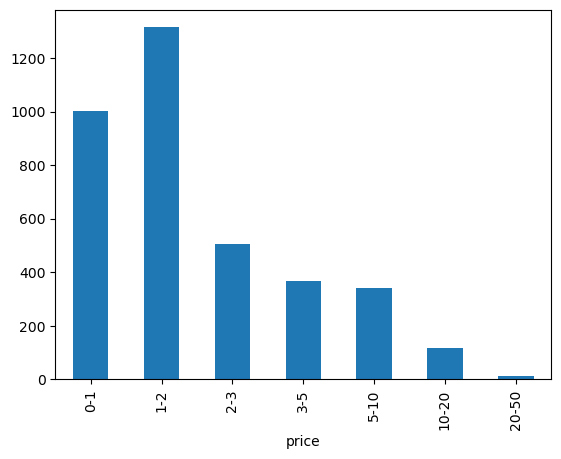

In [65]:
# price binning
bins = [0, 1, 2, 3, 5, 10, 20, 50]
bin_labels = ["0-1", "1-2", "2-3", "3-5", "5-10", "10-20", "20-50"]
pd.cut(df['price'], bins=bins, labels=bin_labels, right=False).value_counts().sort_index().plot(kind='bar')

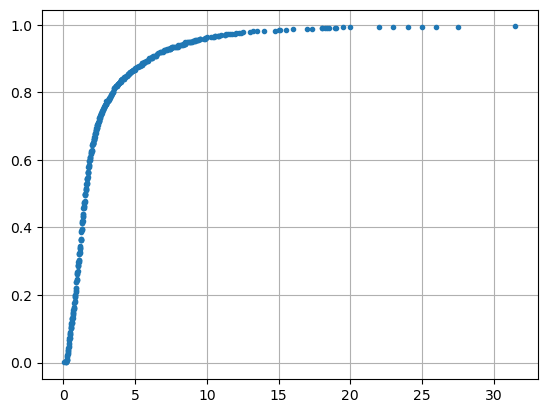

In [67]:
 #ecdf plot
ecdf = df['price'].value_counts().sort_index().cumsum() / len(df['price'])
plt.plot(ecdf.index, ecdf, marker='.', linestyle='none')
plt.grid()

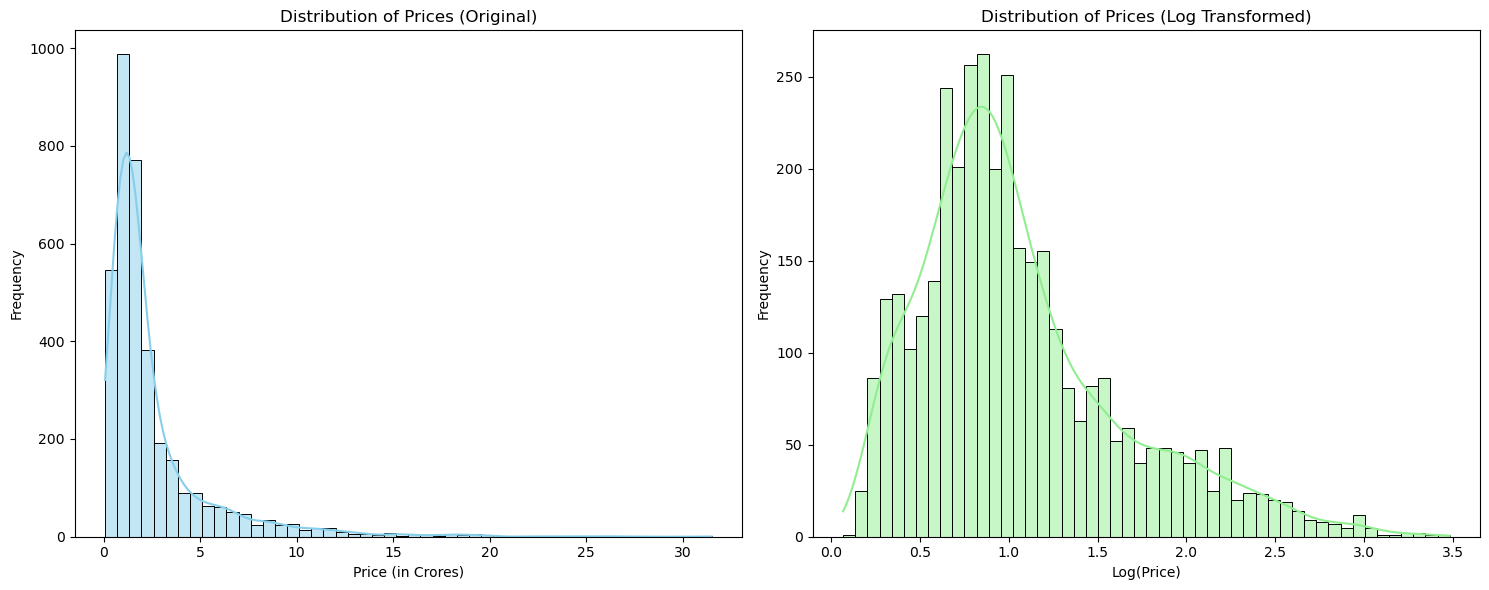

In [69]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['price']), kde=True, bins=50, color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [71]:
skewness = np.log1p(df['price']).skew()
kurtosis = np.log1p(df['price']).kurt()

print(skewness,kurtosis)

1.0732113959861989 0.9625849320972981


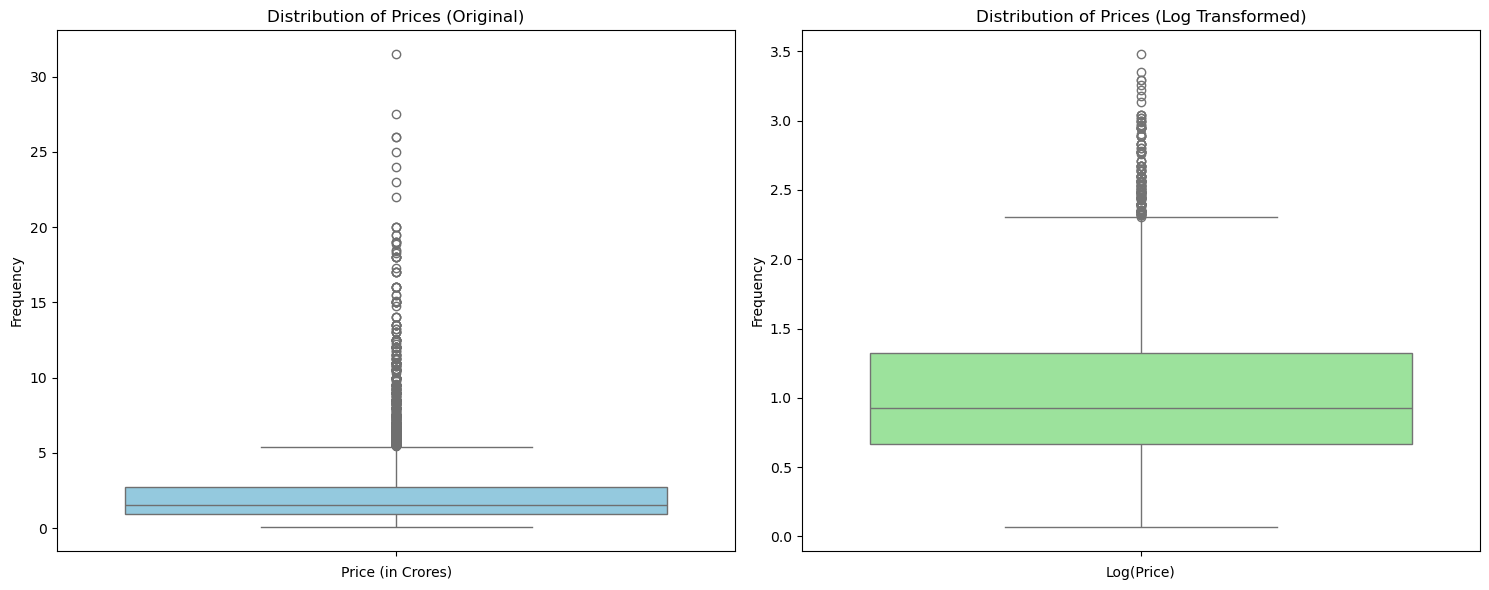

In [73]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.boxplot(df['price'], color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.boxplot(np.log1p(df['price']), color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [75]:
df['price_per_sqft'].isnull().sum()

18

In [77]:
df['price_per_sqft'].describe()

count      3661.000000
mean      13894.272876
std       23207.099280
min           4.000000
25%        6818.000000
50%        9020.000000
75%       13888.000000
max      600000.000000
Name: price_per_sqft, dtype: float64

<Axes: xlabel='price_per_sqft', ylabel='Count'>

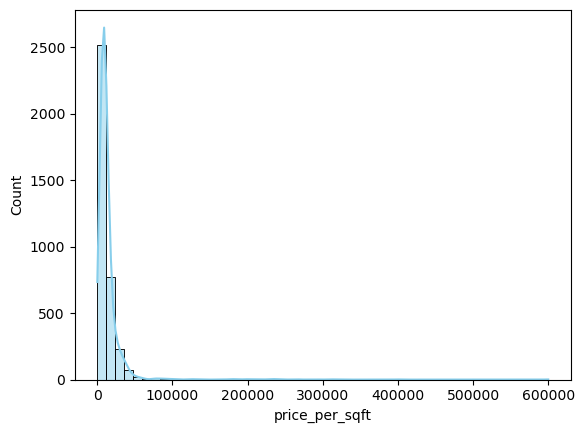

In [79]:
sns.histplot(df['price_per_sqft'], bins=50, color='skyblue', kde=True)

<Axes: ylabel='price_per_sqft'>

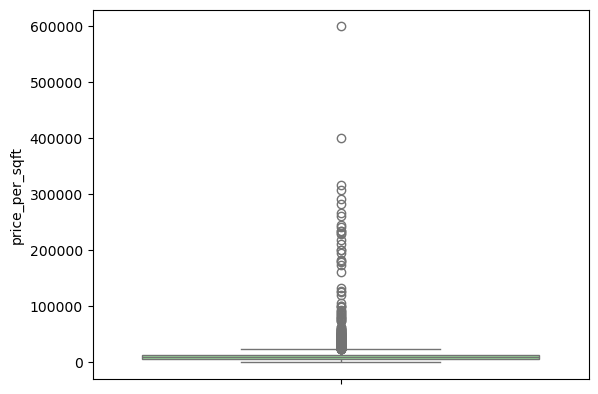

In [81]:
sns.boxplot(df['price_per_sqft'], color='lightgreen')

In [83]:
#bedroom

In [85]:
df['bedRoom'].isnull().sum()

0

<Axes: xlabel='bedRoom'>

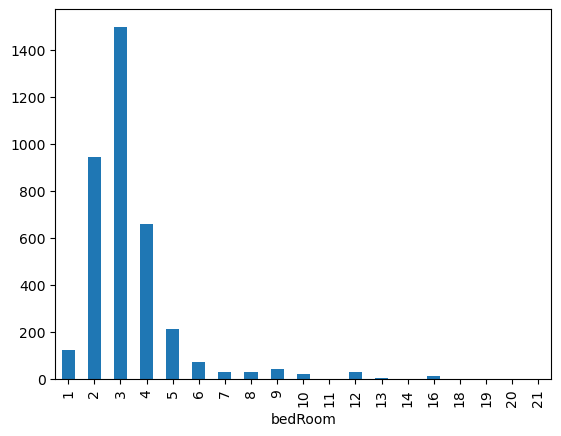

In [87]:
df['bedRoom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

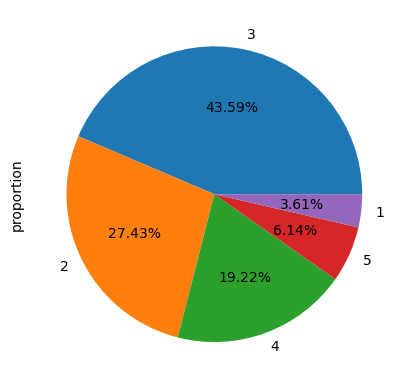

In [89]:
df['bedRoom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

In [91]:
#bathroom

In [93]:
df['bathroom'].isnull().sum()

0

<Axes: xlabel='bathroom'>

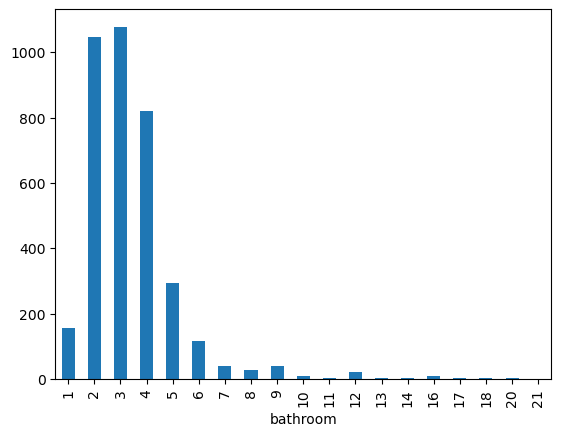

In [95]:
df['bathroom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

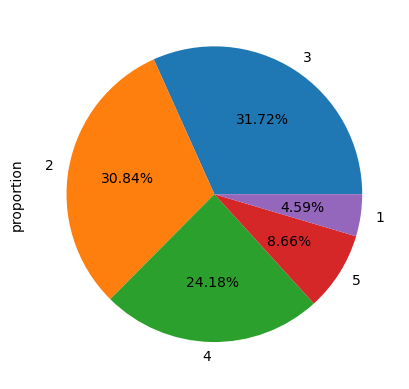

In [97]:
df['bathroom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

In [99]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,mapsko mount ville,sector 79,1.30,8024.0,1620.0,Super Built up area 1620(150.5 sq.m.)Carpet ar...,3,3,2,...,1620.0,NaN,867.24,1,0,0,1,0,0,151
1,flat,experion windchants,sector 112,5.20,10726.0,4848.0,Super Built up area 4848(450.39 sq.m.)Built Up...,4,6,3+,...,4848.0,3655.350000,3500.00,0,1,0,1,0,1,174
2,flat,signature global park,sohna road,0.95,7846.0,1211.0,Built Up area: 1210.73 (112.48 sq.m.)Carpet ar...,3,2,3+,...,NaN,1210.723472,756.60,0,0,0,0,0,0,46
3,house,nirvana cedar crest,sector 50,3.99,8866.0,4500.0,Plot area 4500(418.06 sq.m.),4,5,3+,...,NaN,4500.000000,NaN,0,1,0,0,0,1,112
4,flat,tulip violet,sector 69,1.40,8861.0,1580.0,Super Built up area 1578(146.6 sq.m.),3,3,2,...,1578.0,NaN,NaN,0,0,0,1,0,0,102


In [101]:
#balcony

In [103]:
df['balcony'].isnull().sum()

0

<Axes: xlabel='balcony'>

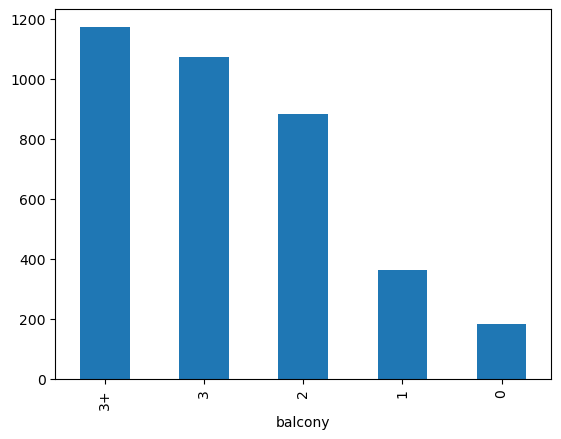

In [105]:
df['balcony'].value_counts().plot(kind='bar')

<Axes: ylabel='proportion'>

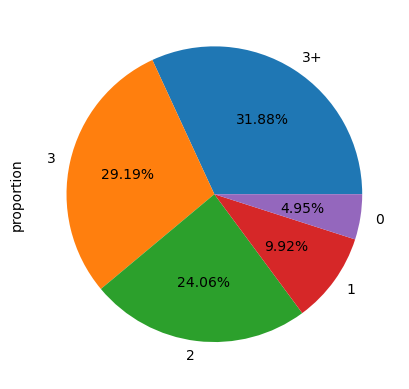

In [107]:
df['balcony'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

In [109]:
##floorNum

In [112]:
df.iloc[:,10:].head()

,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,6.0,West,Relatively New,1620.0,NaN,867.24,1,0,0,1,0,0,151
1,15.0,East,Relatively New,4848.0,3655.350000,3500.00,0,1,0,1,0,1,174
2,1.0,NaN,Relatively New,NaN,1210.723472,756.60,0,0,0,0,0,0,46
3,4.0,North-East,New Property,NaN,4500.000000,NaN,0,1,0,0,0,1,112
4,2.0,North-East,Relatively New,1578.0,NaN,NaN,0,0,0,1,0,0,102


In [114]:
df['floorNum'].isnull().sum()

19

In [116]:
df['floorNum'].describe()

count    3660.000000
mean        6.797541
std         6.010990
min         0.000000
25%         2.000000
50%         5.000000
75%        10.000000
max        51.000000
Name: floorNum, dtype: float64

In [120]:
df['floorNum'].value_counts()

floorNum
3.0     498
2.0     493
1.0     351
4.0     317
8.0     195
6.0     183
10.0    179
7.0     177
5.0     169
9.0     161
12.0    158
0.0     129
11.0    113
14.0    112
15.0     80
16.0     52
17.0     46
13.0     42
18.0     36
19.0     33
20.0     26
21.0     16
23.0     14
22.0     13
24.0     11
25.0      9
27.0      8
30.0      5
26.0      5
28.0      4
33.0      4
31.0      3
29.0      3
34.0      2
39.0      2
32.0      2
35.0      2
43.0      2
45.0      1
44.0      1
40.0      1
38.0      1
51.0      1
Name: count, dtype: int64

<Axes: xlabel='floorNum'>

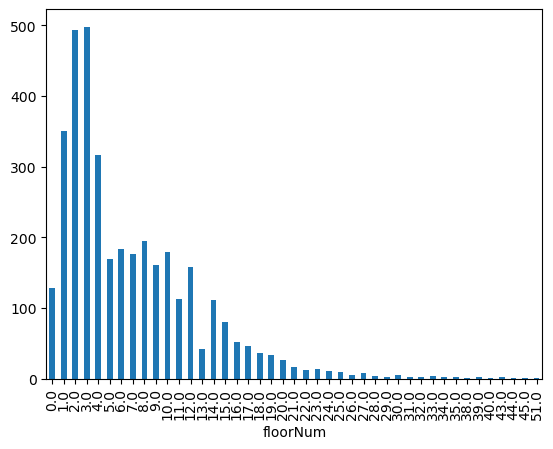

In [118]:
df['floorNum'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='floorNum'>

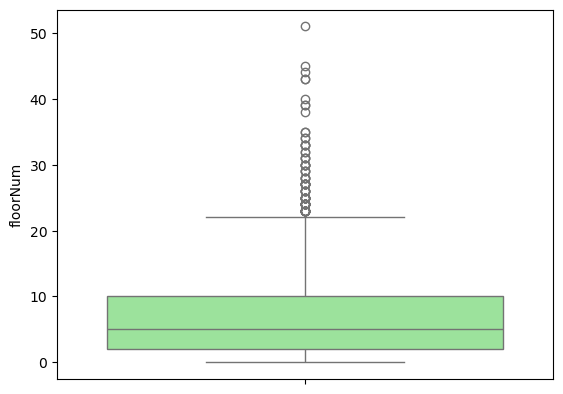

In [122]:
sns.boxplot(df['floorNum'], color='lightgreen')

In [124]:
#facing

In [126]:
df['facing'].isnull().sum()

1045

In [128]:
df['facing'].fillna('NA',inplace=True)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_4536\3692945726.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['facing'].fillna('NA',inplace=True)


In [130]:
df['facing'].value_counts()

facing
NA            1045
East           624
North-East     623
North          387
West           250
South          231
North-West     193
South-East     173
South-West     153
Name: count, dtype: int64

In [132]:
#age possession

In [134]:
df['agePossession'].value_counts()

agePossession
Relatively New        1647
New Property           593
Moderately Old         563
Undefined              306
Old Property           303
Under Construction     267
Name: count, dtype: int64

In [136]:
#area

In [138]:
# super built up area
df['super_built_up_area'].isnull().sum()

1803

In [140]:
df['super_built_up_area'].describe()

count     1876.000000
mean      1925.357436
std        763.985994
min         89.000000
25%       1479.750000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

<Axes: xlabel='super_built_up_area', ylabel='Count'>

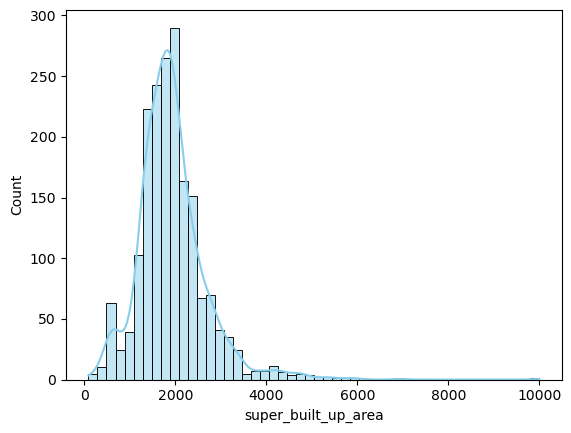

In [142]:
sns.histplot(df['super_built_up_area'].dropna(), bins=50, color='skyblue', kde=True)

<Axes: ylabel='super_built_up_area'>

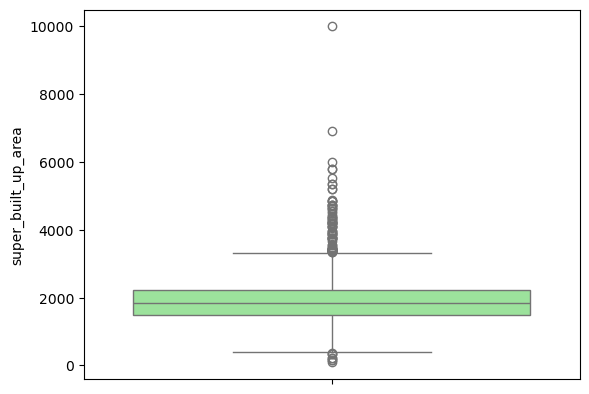

In [144]:
sns.boxplot(df['super_built_up_area'].dropna(), color='lightgreen')

In [146]:
# built up area
df['built_up_area'].isnull().sum()

1988

In [148]:
df['built_up_area'].describe()

count      1691.00000
mean       2378.48612
std       17937.62791
min           2.00000
25%        1100.00000
50%        1650.00000
75%        2400.00000
max      737147.00000
Name: built_up_area, dtype: float64

<Axes: xlabel='built_up_area', ylabel='Count'>

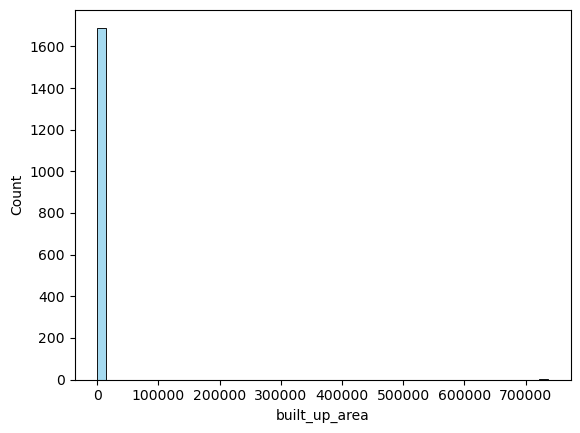

In [150]:
sns.histplot(df['built_up_area'].dropna(), bins=50, color='skyblue', kde=False)

<Axes: ylabel='built_up_area'>

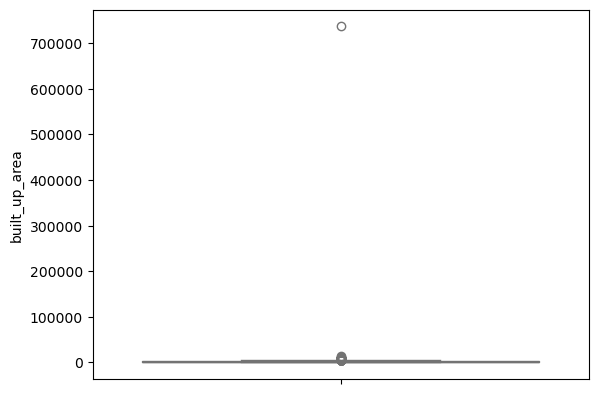

In [152]:
sns.boxplot(df['built_up_area'].dropna(), color='lightgreen')

In [154]:
# carpet area
df['carpet_area'].isnull().sum()

1807

In [156]:
df['carpet_area'].describe()

count      1872.000000
mean       2529.179507
std       22799.836449
min          15.000000
25%         843.000000
50%        1300.000000
75%        1790.000000
max      607936.000000
Name: carpet_area, dtype: float64

<Axes: xlabel='carpet_area', ylabel='Count'>

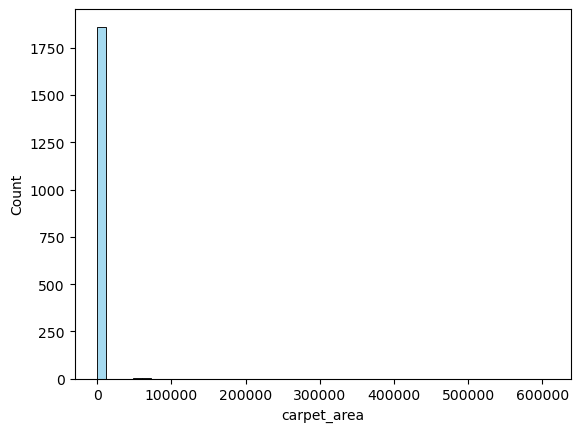

In [158]:
sns.histplot(df['carpet_area'].dropna(), bins=50, color='skyblue', kde=False)

<Axes: ylabel='carpet_area'>

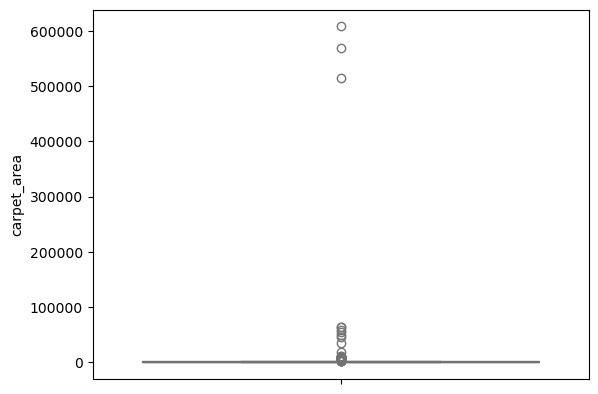

In [160]:
sns.boxplot(df['carpet_area'].dropna(), color='lightgreen')

In [164]:
df.iloc[:,16:]

,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,1,0,0,1,0,0,151
1,0,1,0,1,0,1,174
2,0,0,0,0,0,0,46
3,0,1,0,0,0,1,112
4,0,0,0,1,0,0,102
...,...,...,...,...,...,...,...
3798,0,1,0,0,0,0,0
3799,1,1,0,0,0,0,8
3800,1,0,0,0,0,0,104
3801,0,1,0,0,1,0,33


In [166]:
#additional Rooms

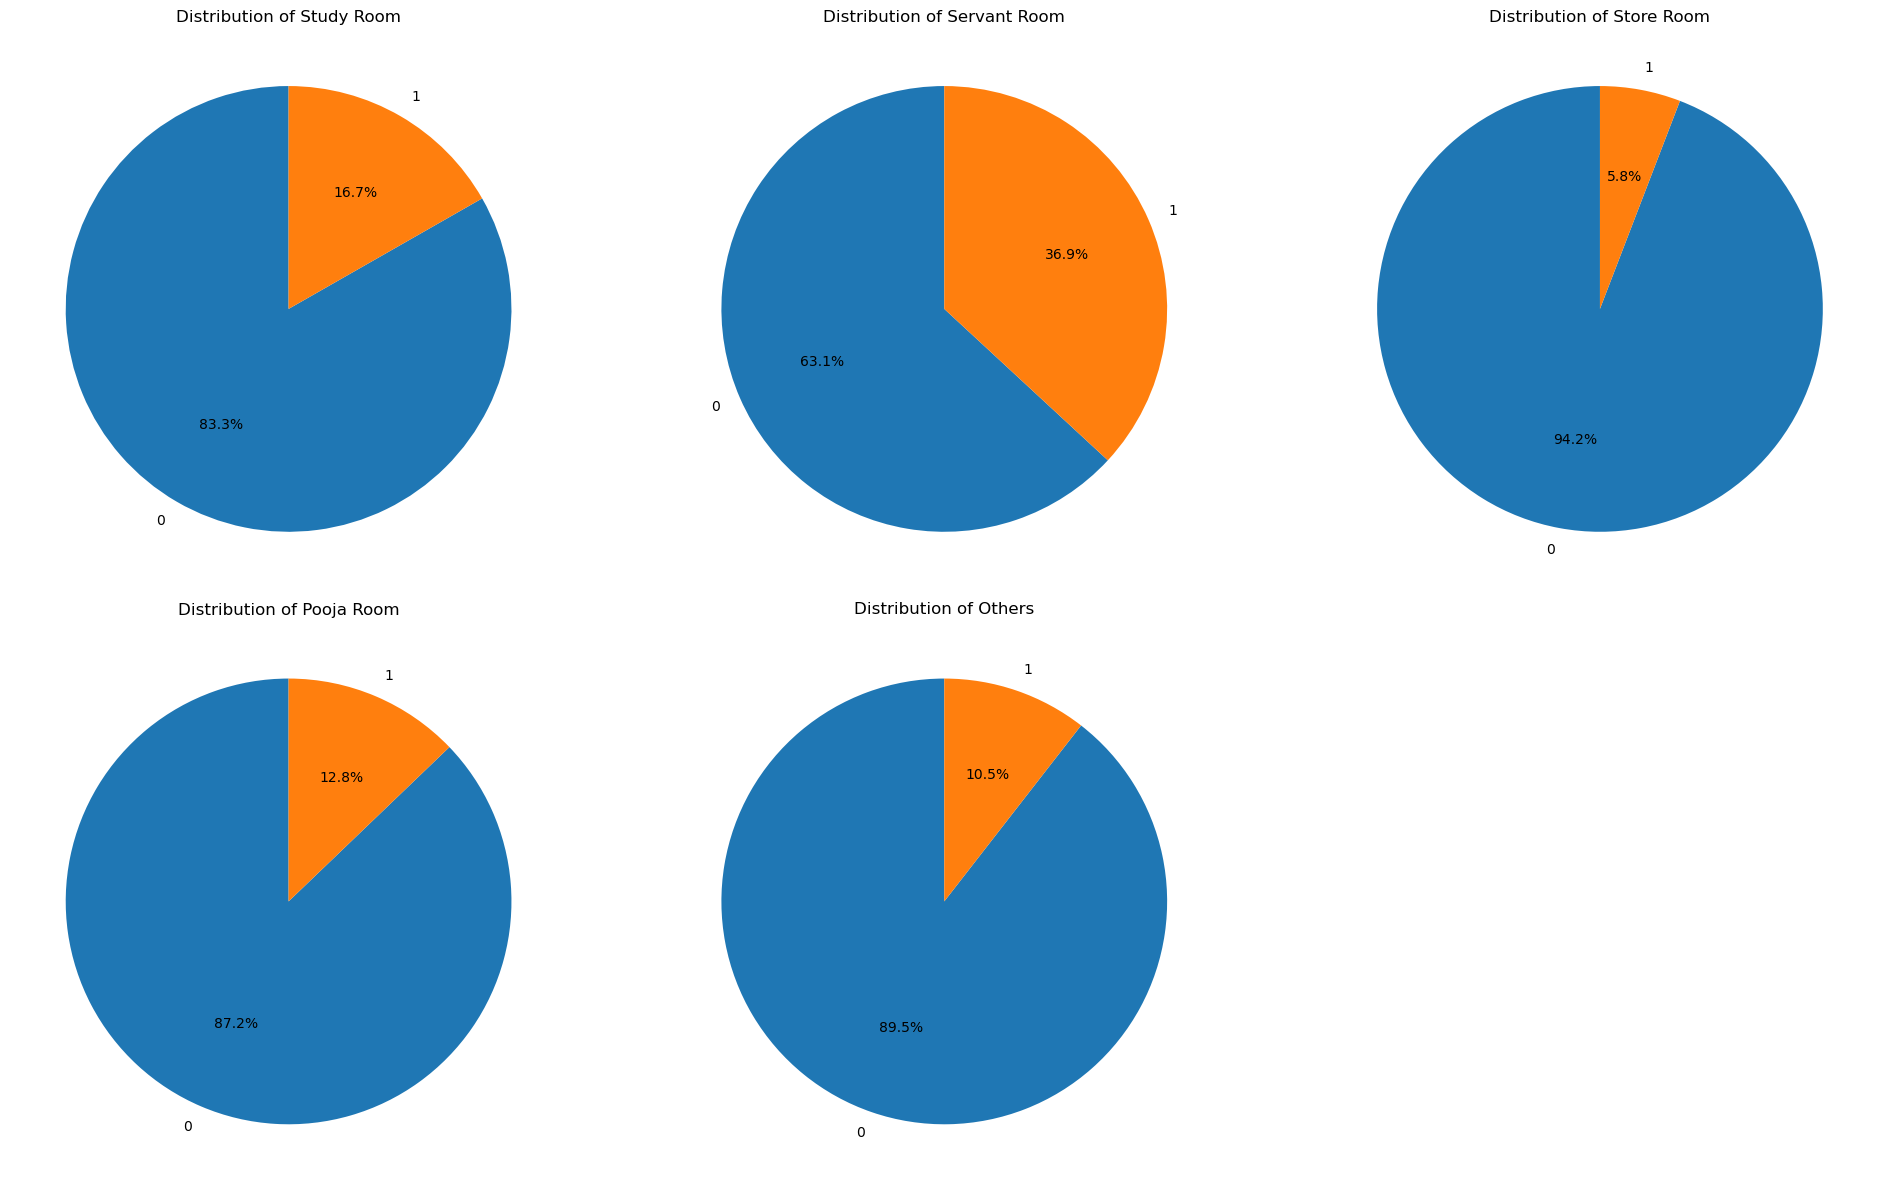

In [168]:
plt.figure(figsize=(20, 12))

# Create a subplot of pie charts for each room type
for idx, room in enumerate(['study room','servant room','store room','pooja room','others'], 1):
    ax = plt.subplot(2, 3, idx)
    df[room].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, ax=ax)
    plt.title(f'Distribution of {room.title()}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

In [170]:
#furnishing Type

In [172]:
df['furnishing_type'].value_counts()

furnishing_type
0    2437
1    1039
2     203
Name: count, dtype: int64

<Axes: ylabel='count'>

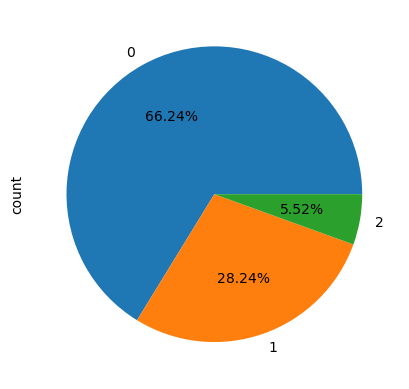

In [174]:
df['furnishing_type'].value_counts().plot(kind='pie',autopct='%0.2f%%')

In [176]:
#luxury Score


In [178]:
df['luxury_score'].isnull().sum()

0

In [180]:
df['luxury_score'].describe()

count    3679.000000
mean       71.512639
std        53.048966
min         0.000000
25%        31.000000
50%        59.000000
75%       110.000000
max       174.000000
Name: luxury_score, dtype: float64

<Axes: xlabel='luxury_score', ylabel='Count'>

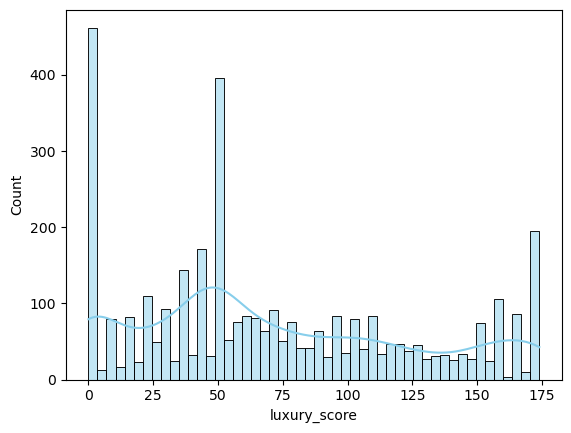

In [182]:
sns.histplot(df['luxury_score'], bins=50, color='skyblue', kde=True)

<Axes: ylabel='luxury_score'>

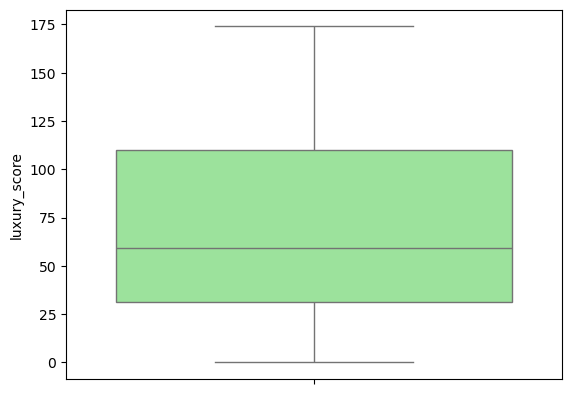

In [184]:
sns.boxplot(df['luxury_score'], color='lightgreen')

In [186]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,mapsko mount ville,sector 79,1.30,8024.0,1620.0,Super Built up area 1620(150.5 sq.m.)Carpet ar...,3,3,2,...,1620.0,NaN,867.24,1,0,0,1,0,0,151
1,flat,experion windchants,sector 112,5.20,10726.0,4848.0,Super Built up area 4848(450.39 sq.m.)Built Up...,4,6,3+,...,4848.0,3655.350000,3500.00,0,1,0,1,0,1,174
2,flat,signature global park,sohna road,0.95,7846.0,1211.0,Built Up area: 1210.73 (112.48 sq.m.)Carpet ar...,3,2,3+,...,NaN,1210.723472,756.60,0,0,0,0,0,0,46
3,house,nirvana cedar crest,sector 50,3.99,8866.0,4500.0,Plot area 4500(418.06 sq.m.),4,5,3+,...,NaN,4500.000000,NaN,0,1,0,0,0,1,112
4,flat,tulip violet,sector 69,1.40,8861.0,1580.0,Super Built up area 1578(146.6 sq.m.),3,3,2,...,1578.0,NaN,NaN,0,0,0,1,0,0,102
